# Lab 2: FRED stock index comparison in R

## Project title
**Risk and Return Across U.S. Equity Indices: A FRED API Analysis**

## Research question
How have the **S&P 500**, **NASDAQ-100**, **NASDAQ Composite**, and **PHLX Semiconductor Index** performed relative to each other since 2019 — in terms of raw cumulative returns, daily volatility, correlation, and risk-adjusted performance — and does higher raw return translate proportionally into higher risk-adjusted return?

## Why this question matters
These indices represent different parts of the U.S. equity market. The S&P 500 is a broad large-cap benchmark. The NASDAQ-100 is more concentrated in large non-financial Nasdaq-listed firms, especially technology and growth companies. The NASDAQ Composite is broader across Nasdaq-listed equities. The PHLX Semiconductor Index adds a more concentrated semiconductor angle, which is especially relevant because semiconductors are central to AI, cloud computing, data centers, and advanced technology.

The question matters because raw return figures alone can be misleading. An index that gained more may have also required tolerating significantly higher volatility and deeper drawdowns. Investors, financial advisors, analysts, and portfolio managers need to know not only **which index returned the most**, but also **whether that return was proportionally compensated for the additional risk taken** — and whether holding multiple Nasdaq-linked indices provides genuine diversification or simply redundant exposure.

## Data source

The data comes from **Federal Reserve Economic Data (FRED)**, maintained by the Federal Reserve Bank of St. Louis.

- Source type: Public API
- API/package used in R: `fredr`
- FRED API documentation: https://fred.stlouisfed.org/docs/api/fred/
- `fredr` package documentation: https://sboysel.github.io/fredr/

The `fredr` package is an R client for the FRED API. The core function used here is `fredr()`, which retrieves observations for a selected FRED series.

## Series selected

| FRED code | Full series name | Why included |
|---|---|---|
| `SP500` | S&P 500 | Broad large-cap U.S. equity benchmark |
| `NASDAQ100` | NASDAQ-100 | Large Nasdaq-listed non-financial companies, strong technology/growth tilt |
| `NASDAQCOM` | NASDAQ Composite | Broader Nasdaq-listed equity market |
| `NASDAQSOX` | PHLX Semiconductor | Semiconductor-sector exposure, relevant to AI and technology infrastructure |
| `TB3MS` | 3-Month Treasury Bill Rate | Risk-free rate proxy used to calculate risk-adjusted performance (Sharpe Ratio) |

## 1. Install and load packages

This cell installs and loads the R packages needed for the lab. If the packages are already installed, R may skip or quickly confirm installation.

In [2]:
packages <- c("fredr", "dplyr", "tidyr", "ggplot2", "purrr", "knitr", "zoo", "gt", "IRdisplay")

installed <- rownames(installed.packages())
for (pkg in packages) {
  if (!(pkg %in% installed)) {
    install.packages(pkg)
  }
}

library(fredr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(purrr)
library(knitr)
library(zoo)
library(gt)
library(IRdisplay)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




## Style constants

All colors, fonts, and sizes used across charts and tables are defined here. Change a value once to update the whole notebook.

In [3]:
# ── Index colors (used in all charts and the gt table) ───────────────────────
index_colors <- c(
  "PHLX Semiconductor" = "#e74c3c",
  "NASDAQ-100"         = "#3498db",
  "NASDAQ Composite"   = "#2ecc71",
  "S&P 500"            = "#95a5a6"
)

# ── Positive / negative day colors (daily returns chart) ─────────────────────
color_pos <- "#2ecc71"
color_neg <- "#e74c3c"

# ── Table header colors ───────────────────────────────────────────────────────
color_header_bg   <- "#2c3e50"
color_header_text <- "white"
color_highlight   <- "#d5f5e3"

# ── Chart dimensions ──────────────────────────────────────────────────────────
plot_width_wide   <- 12
plot_width_normal <- 10
plot_height_std   <- 6
plot_height_tall  <- 8
plot_height_short <- 5

# ── Typography ────────────────────────────────────────────────────────────────
font_base    <- 14
font_title   <- 18
font_subtitle <- 13
font_axis    <- 12
font_legend  <- 13
font_strip   <- 13

## 2. Set the FRED API key

Replace `PASTE_YOUR_FRED_API_KEY_HERE` with your actual FRED API key before running the cell.

Important: do not submit a public notebook with your real API key visible. After the data has been downloaded, you can clear the output or use an environment variable instead.

In [4]:
# Option 1, simplest for this lab: paste your key inside the quotation marks.
fredr_set_key("bfbc1b176969fd64a4ea2c97b8f93c74")

# Check whether fredr sees an API key.
fredr_has_key()

[1] TRUE

## 3. Define the selected FRED series

This table records the selected series and their interpretation. The analysis starts on January 1, 2019, giving several years of data including the COVID shock, the 2022 rate-hike/inflation period, and the later AI/technology-driven market recovery.

In [5]:
start_date <- as.Date("2019-01-01")

series_info <- tibble::tibble(
  series_id = c("SP500", "NASDAQ100", "NASDAQCOM", "NASDAQSOX"),
  index_name = c("S&P 500", "NASDAQ-100", "NASDAQ Composite", "PHLX Semiconductor"),
  description = c(
    "Broad large-cap U.S. equity benchmark",
    "Large Nasdaq-listed non-financial companies",
    "Broader Nasdaq-listed equity market",
    "Semiconductor-sector index"
  )
)

series_info

series_id,index_name,description
<chr>,<chr>,<chr>
SP500,S&P 500,Broad large-cap U.S. equity benchmark
NASDAQ100,NASDAQ-100,Large Nasdaq-listed non-financial companies
NASDAQCOM,NASDAQ Composite,Broader Nasdaq-listed equity market
NASDAQSOX,PHLX Semiconductor,Semiconductor-sector index


## 4. Import the data from FRED

The function below calls the FRED API once for each series. The result is combined into one long-format dataset.

In [6]:
get_fred_series <- function(id) {
  fredr(
    series_id = id,
    observation_start = start_date
  ) %>%
    select(date, series_id, value)
}

raw_index_data <- map_dfr(series_info$series_id, get_fred_series) %>%
  left_join(series_info, by = "series_id")

head(raw_index_data)

date,series_id,value,index_name,description
<date>,<chr>,<dbl>,<chr>,<chr>
2019-01-01,SP500,NA,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-02,SP500,2510.03,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-03,SP500,2447.89,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-04,SP500,2531.94,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-07,SP500,2549.69,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-08,SP500,2574.41,S&P 500,Broad large-cap U.S. equity benchmark


## 5. Show the data structure

The lab asks for basic inspection of the imported dataset. These commands show the first rows, structure, dimensions, column names, and summary statistics.

In [7]:
head(raw_index_data)
str(raw_index_data)
dim(raw_index_data)
names(raw_index_data)
summary(raw_index_data)

date,series_id,value,index_name,description
<date>,<chr>,<dbl>,<chr>,<chr>
2019-01-01,SP500,NA,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-02,SP500,2510.03,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-03,SP500,2447.89,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-04,SP500,2531.94,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-07,SP500,2549.69,S&P 500,Broad large-cap U.S. equity benchmark
2019-01-08,SP500,2574.41,S&P 500,Broad large-cap U.S. equity benchmark


tibble [7,716 × 5] (S3: tbl_df/tbl/data.frame)
 $ date       : Date[1:7716], format: "2019-01-01" "2019-01-02" ...
 $ series_id  : chr [1:7716] "SP500" "SP500" "SP500" "SP500" ...
 $ value      : num [1:7716] NA 2510 2448 2532 2550 ...
 $ index_name : chr [1:7716] "S&P 500" "S&P 500" "S&P 500" "S&P 500" ...
 $ description: chr [1:7716] "Broad large-cap U.S. equity benchmark" "Broad large-cap U.S. equity benchmark" "Broad large-cap U.S. equity benchmark" "Broad large-cap U.S. equity benchmark" ...


[1] 7716    5

[1] "date"        "series_id"   "value"       "index_name"  "description"

      date                series_id        value           index_name  
 Min.   :2019-01-01   Length   :7716   Min.   : 1096   Length   :7716  
 1st Qu.:2020-11-05   N.unique :   4   1st Qu.: 3901   N.unique :   4  
 Median :2022-09-12   N.blank  :   0   Median : 7373   N.blank  :   0  
 Mean   :2022-09-11   Min.nchar:   5   Mean   : 9329   Min.nchar:   7  
 3rd Qu.:2024-07-17   Max.nchar:   9   3rd Qu.:13802   Max.nchar:  18  
 Max.   :2026-05-22                    Max.   :29580                   
                                       NAs    :282                     
    description  
 Length   :7716  
 N.unique :   4  
 N.blank  :   0  
 Min.nchar:  26  
 Max.nchar:  43  
                 
                 

## 6. Explain the main variables

| Variable | Meaning | Type | Why it matters |
|---|---|---|---|
| `date` | Date of observation | Date | Allows the indices to be compared over time |
| `series_id` | FRED series code | Categorical | Identifies the specific FRED dataset |
| `value` | Index level | Numerical | Main measure of each index's market value |
| `index_name` | Human-readable index name | Categorical | Makes tables and charts easier to interpret |
| `description` | Short explanation of index | Categorical | Explains the role of each series in the analysis |

## 7. Basic data cleaning checks

The goal is not to perform advanced cleaning, but to check whether the dataset has missing values, duplicate rows, or unexpected series labels.

In [8]:
# Total missing values in the full dataset
sum(is.na(raw_index_data))

# Missing values by column
colSums(is.na(raw_index_data))

# Duplicate full rows
sum(duplicated(raw_index_data))

# Confirm the series labels
unique(raw_index_data$series_id)
unique(raw_index_data$index_name)

# Count observations by index
table(raw_index_data$index_name)

[1] 282

date   series_id       value  index_name description 
          0           0         282           0           0

[1] 0

[1] "SP500"     "NASDAQ100" "NASDAQCOM" "NASDAQSOX"

[1] "S&P 500"            "NASDAQ-100"         "NASDAQ Composite"  
[4] "PHLX Semiconductor"


        NASDAQ-100   NASDAQ Composite PHLX Semiconductor            S&P 500 
              1929               1929               1929               1929 

## 8. Reshape the data into wide format

The long format is good for plotting by category. The wide format is better for calculating returns and comparing columns directly.

In [9]:
index_wide <- raw_index_data %>%
  select(date, index_name, value) %>%
  pivot_wider(names_from = index_name, values_from = value) %>%
  arrange(date)

head(index_wide)
str(index_wide)
summary(index_wide)

date,S&P 500,NASDAQ-100,NASDAQ Composite,PHLX Semiconductor
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2019-01-01,NA,NA,NA,NA
2019-01-02,2510.03,6360.87,6665.94,1165.30
2019-01-03,2447.89,6147.13,6463.50,1096.03
2019-01-04,2531.94,6422.67,6738.86,1143.96
2019-01-07,2549.69,6488.25,6823.47,1166.24
2019-01-08,2574.41,6551.85,6897.00,1160.55


tibble [1,929 × 5] (S3: tbl_df/tbl/data.frame)
 $ date              : Date[1:1929], format: "2019-01-01" "2019-01-02" ...
 $ S&P 500           : num [1:1929] NA 2510 2448 2532 2550 ...
 $ NASDAQ-100        : num [1:1929] NA 6361 6147 6423 6488 ...
 $ NASDAQ Composite  : num [1:1929] NA 6666 6464 6739 6823 ...
 $ PHLX Semiconductor: num [1:1929] NA 1165 1096 1144 1166 ...


      date               S&P 500       NASDAQ-100    NASDAQ Composite
 Min.   :2019-01-01   Min.   :2237   Min.   : 6147   Min.   : 6464   
 1st Qu.:2020-11-05   1st Qu.:3516   1st Qu.:11275   1st Qu.:10961   
 Median :2022-09-12   Median :4288   Median :14238   Median :13631   
 Mean   :2022-09-11   Mean   :4482   Mean   :15016   Mean   :14148   
 3rd Qu.:2024-07-17   3rd Qu.:5426   3rd Qu.:18945   3rd Qu.:17142   
 Max.   :2026-05-22   Max.   :7501   Max.   :29580   Max.   :26635   
                      NAs    :71     NAs    :70      NAs    :70      
 PHLX Semiconductor
 Min.   : 1096     
 1st Qu.: 2338     
 Median : 3253     
 Mean   : 3665     
 3rd Qu.: 4800     
 Max.   :12203     
 NAs    :71        

## 9. Clean the wide dataset

Because all four series are daily market series, some dates may not line up perfectly because of holidays, missing observations, or release differences. For comparison, this notebook keeps only dates where all selected indices have observations.

In [10]:
index_clean <- index_wide %>%
  drop_na()

# Compare row counts before and after dropping missing rows
nrow(index_wide)
nrow(index_clean)

# Confirm no missing values remain
colSums(is.na(index_clean))

[1] 1929

[1] 1858

date            S&P 500         NASDAQ-100   NASDAQ Composite 
                 0                  0                  0                  0 
PHLX Semiconductor 
                 0

## 9b. Import the 3-Month T-Bill rate (risk-free rate)

The 3-Month Treasury Bill rate (`TB3MS`) is fetched separately because it is a monthly series, whereas the index data is daily. It will be used later to compute the Sharpe Ratio. `TB3MS` is reported as an annualized percentage (e.g. 5.25 means 5.25% per year), so it is converted to a daily equivalent before use.

The 3-Month T-Bill is the standard risk-free rate proxy in the Sharpe Ratio literature. It represents the return an investor could earn with essentially zero credit risk, making it the appropriate baseline against which to measure equity performance.

In [11]:
# Fetch monthly T-Bill rate and forward-fill to daily frequency
tbill_raw <- fredr(series_id = "TB3MS", observation_start = start_date) %>%
  select(date, tbill_annual_pct = value) %>%
  drop_na()

# Convert annualised % rate to a daily decimal return equivalent
# Formula: daily_rf = (1 + annual_rate/100)^(1/252) - 1
tbill_daily <- tbill_raw %>%
  mutate(rf_daily = (1 + tbill_annual_pct / 100)^(1 / 252) - 1)

# Forward-fill monthly observations to match daily index dates
tbill_ff <- index_clean %>%
  select(date) %>%
  left_join(tbill_daily, by = "date") %>%
  arrange(date) %>%
  fill(rf_daily, .direction = "down")

head(tbill_ff)
summary(tbill_ff$rf_daily)

date,tbill_annual_pct,rf_daily
<date>,<dbl>,<dbl>
2019-01-02,NA,NA
2019-01-03,NA,NA
2019-01-04,NA,NA
2019-01-07,NA,NA
2019-01-08,NA,NA
2019-01-09,NA,NA


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max.       NAs 
7.936e-07 6.344e-06 1.223e-04 1.058e-04 1.716e-04 2.057e-04        21 

## 10. Date range and latest index levels

These outputs make the notebook easier to interpret after it is run. The date range confirms the final sample period after missing observations are removed. The latest values show the most recent available index levels in the FRED data.

In [12]:
date_range <- index_clean %>%
  summarize(
    start_date = min(date, na.rm = TRUE),
    end_date = max(date, na.rm = TRUE),
    observations = n()
  )

date_range

latest_values <- index_clean %>%
  filter(date == max(date, na.rm = TRUE))

latest_values

start_date,end_date,observations
<date>,<date>,<int>
2019-01-02,2026-05-22,1858


date,S&P 500,NASDAQ-100,NASDAQ Composite,PHLX Semiconductor
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2026-05-22,7473.47,29481.64,26343.97,12202.54


## 10. Normalize the index levels

Raw index levels are not directly comparable because each index has a different base value. To compare performance, each index is normalized to start at 100 on the first available date in the cleaned dataset.

In [13]:
index_normalized <- index_clean %>%
  mutate(
    `S&P 500 Normalized` = `S&P 500` / first(`S&P 500`) * 100,
    `NASDAQ-100 Normalized` = `NASDAQ-100` / first(`NASDAQ-100`) * 100,
    `NASDAQ Composite Normalized` = `NASDAQ Composite` / first(`NASDAQ Composite`) * 100,
    `PHLX Semiconductor Normalized` = `PHLX Semiconductor` / first(`PHLX Semiconductor`) * 100
  )

head(index_normalized)

date,S&P 500,NASDAQ-100,NASDAQ Composite,PHLX Semiconductor,S&P 500 Normalized,NASDAQ-100 Normalized,NASDAQ Composite Normalized,PHLX Semiconductor Normalized
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2019-01-02,2510.03,6360.87,6665.94,1165.30,100.00000,100.00000,100.00000,100.00000
2019-01-03,2447.89,6147.13,6463.50,1096.03,97.52433,96.63977,96.96307,94.05561
2019-01-04,2531.94,6422.67,6738.86,1143.96,100.87290,100.97157,101.09392,98.16871
2019-01-07,2549.69,6488.25,6823.47,1166.24,101.58006,102.00256,102.36321,100.08067
2019-01-08,2574.41,6551.85,6897.00,1160.55,102.56491,103.00242,103.46628,99.59238
2019-01-09,2584.96,6600.69,6957.08,1189.84,102.98522,103.77024,104.36758,102.10590


## Total percentage change since the start date

This table compares cumulative performance over the sample period. It is more meaningful than comparing raw index levels because each index starts from a different base value.

In [14]:
total_change <- index_clean %>%
  summarize(
    start_date = min(date, na.rm = TRUE),
    end_date = max(date, na.rm = TRUE),
    sp500_total_change_pct = (last(`S&P 500`) / first(`S&P 500`) - 1) * 100,
    nasdaq100_total_change_pct = (last(`NASDAQ-100`) / first(`NASDAQ-100`) - 1) * 100,
    nasdaqcom_total_change_pct = (last(`NASDAQ Composite`) / first(`NASDAQ Composite`) - 1) * 100,
    nasdaqsox_total_change_pct = (last(`PHLX Semiconductor`) / first(`PHLX Semiconductor`) - 1) * 100
  )

total_change

start_date,end_date,sp500_total_change_pct,nasdaq100_total_change_pct,nasdaqcom_total_change_pct,nasdaqsox_total_change_pct
<date>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
2019-01-02,2026-05-22,197.7443,363.4844,295.2026,947.1587


## 11. Calculate daily returns

Daily returns make volatility comparisons more meaningful than raw index levels. The formula is:

\[
\text{Daily Return} = \left(\frac{\text{Today's Value}}{\text{Previous Day's Value}} - 1\right) \times 100
\]

In [15]:
index_returns <- index_clean %>%
  arrange(date) %>%
  mutate(
    `S&P 500 Return` = (`S&P 500` / lag(`S&P 500`) - 1) * 100,
    `NASDAQ-100 Return` = (`NASDAQ-100` / lag(`NASDAQ-100`) - 1) * 100,
    `NASDAQ Composite Return` = (`NASDAQ Composite` / lag(`NASDAQ Composite`) - 1) * 100,
    `PHLX Semiconductor Return` = (`PHLX Semiconductor` / lag(`PHLX Semiconductor`) - 1) * 100
  )

head(index_returns)
summary(index_returns)

date,S&P 500,NASDAQ-100,NASDAQ Composite,PHLX Semiconductor,S&P 500 Return,NASDAQ-100 Return,NASDAQ Composite Return,PHLX Semiconductor Return
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2019-01-02,2510.03,6360.87,6665.94,1165.30,NA,NA,NA,NA
2019-01-03,2447.89,6147.13,6463.50,1096.03,-2.4756676,-3.3602322,-3.0369310,-5.9443920
2019-01-04,2531.94,6422.67,6738.86,1143.96,3.4335693,4.4824170,4.2602305,4.3730555
2019-01-07,2549.69,6488.25,6823.47,1166.24,0.7010435,1.0210707,1.2555536,1.9476205
2019-01-08,2574.41,6551.85,6897.00,1160.55,0.9695296,0.9802335,1.0776042,-0.4878927
2019-01-09,2584.96,6600.69,6957.08,1189.84,0.4098026,0.7454383,0.8711034,2.5238034


      date               S&P 500       NASDAQ-100    NASDAQ Composite
 Min.   :2019-01-02   Min.   :2237   Min.   : 6147   Min.   : 6464   
 1st Qu.:2020-11-03   1st Qu.:3516   1st Qu.:11278   1st Qu.:10965   
 Median :2022-09-08   Median :4288   Median :14241   Median :13631   
 Mean   :2022-09-10   Mean   :4482   Mean   :15019   Mean   :14151   
 3rd Qu.:2024-07-16   3rd Qu.:5426   3rd Qu.:18952   3rd Qu.:17145   
 Max.   :2026-05-22   Max.   :7501   Max.   :29580   Max.   :26635   
                                                                     
 PHLX Semiconductor S&P 500 Return      NASDAQ-100 Return  
 Min.   : 1096      Min.   :-11.98405   Min.   :-12.19322  
 1st Qu.: 2338      1st Qu.: -0.43394   1st Qu.: -0.59889  
 Median : 3253      Median :  0.09801   Median :  0.15305  
 Mean   : 3665      Mean   :  0.06646   Mean   :  0.09431  
 3rd Qu.: 4800      3rd Qu.:  0.67281   3rd Qu.:  0.89605  
 Max.   :12203      Max.   :  9.51539   Max.   : 12.02230  
                    

## 12. Early statistical exploration

The table below calculates basic statistics for daily returns. The standard deviation is especially useful because it gives a simple measure of volatility.

In [16]:
return_stats <- index_returns %>%
  select(date, ends_with("Return")) %>%
  pivot_longer(cols = -date, names_to = "index", values_to = "daily_return") %>%
  group_by(index) %>%
  summarize(
    observations = sum(!is.na(daily_return)),
    mean_return = mean(daily_return, na.rm = TRUE),
    median_return = median(daily_return, na.rm = TRUE),
    sd_return = sd(daily_return, na.rm = TRUE),
    min_return = min(daily_return, na.rm = TRUE),
    max_return = max(daily_return, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(sd_return))

return_stats

index,observations,mean_return,median_return,sd_return,min_return,max_return
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PHLX Semiconductor Return,1857,0.15352924,0.16380236,2.322624,-15.89629,18.73481
NASDAQ-100 Return,1857,0.09430727,0.15305258,1.528089,-12.19322,12.02230
NASDAQ Composite Return,1857,0.08535804,0.14341233,1.503824,-12.32133,12.16316
S&P 500 Return,1857,0.06646173,0.09801272,1.238308,-11.98405,9.51539


## Cleaner volatility ranking

The standard deviation of daily returns is a simple volatility measure. Higher standard deviation means larger typical daily movements.

In [17]:
volatility_table <- return_stats %>%
  select(index, observations, daily_return_sd = sd_return) %>%
  arrange(desc(daily_return_sd))

volatility_table

index,observations,daily_return_sd
<chr>,<int>,<dbl>
PHLX Semiconductor Return,1857,2.322624
NASDAQ-100 Return,1857,1.528089
NASDAQ Composite Return,1857,1.503824
S&P 500 Return,1857,1.238308


## 13. Correlation of daily returns

This shows how closely the indices move together on a daily percentage-change basis. High correlation between two indices means they tend to rise and fall together — holding both provides little diversification benefit because losses in one are not offset by gains in the other.

In [18]:
return_matrix <- index_returns %>%
  select(ends_with("Return"))

cor(return_matrix, use = "complete.obs")

,S&P 500 Return,NASDAQ-100 Return,NASDAQ Composite Return,PHLX Semiconductor Return
S&P 500 Return,1.0000000,0.9381203,0.9504915,0.8270641
NASDAQ-100 Return,0.9381203,1.0000000,0.9934359,0.8861150
NASDAQ Composite Return,0.9504915,0.9934359,1.0000000,0.8832004
PHLX Semiconductor Return,0.8270641,0.8861150,0.8832004,1.0000000


## Named correlation matrix

The correlation matrix shows how closely the indices move together based on daily returns. Values close to 1 mean the indices usually move in the same direction on the same day.

In [19]:
correlation_matrix <- cor(return_matrix, use = "complete.obs")

correlation_matrix

,S&P 500 Return,NASDAQ-100 Return,NASDAQ Composite Return,PHLX Semiconductor Return
S&P 500 Return,1.0000000,0.9381203,0.9504915,0.8270641
NASDAQ-100 Return,0.9381203,1.0000000,0.9934359,0.8861150
NASDAQ Composite Return,0.9504915,0.9934359,1.0000000,0.8832004
PHLX Semiconductor Return,0.8270641,0.8861150,0.8832004,1.0000000


## 14. Plot normalized index performance

This chart compares cumulative performance by setting each index equal to 100 at the start of the sample.

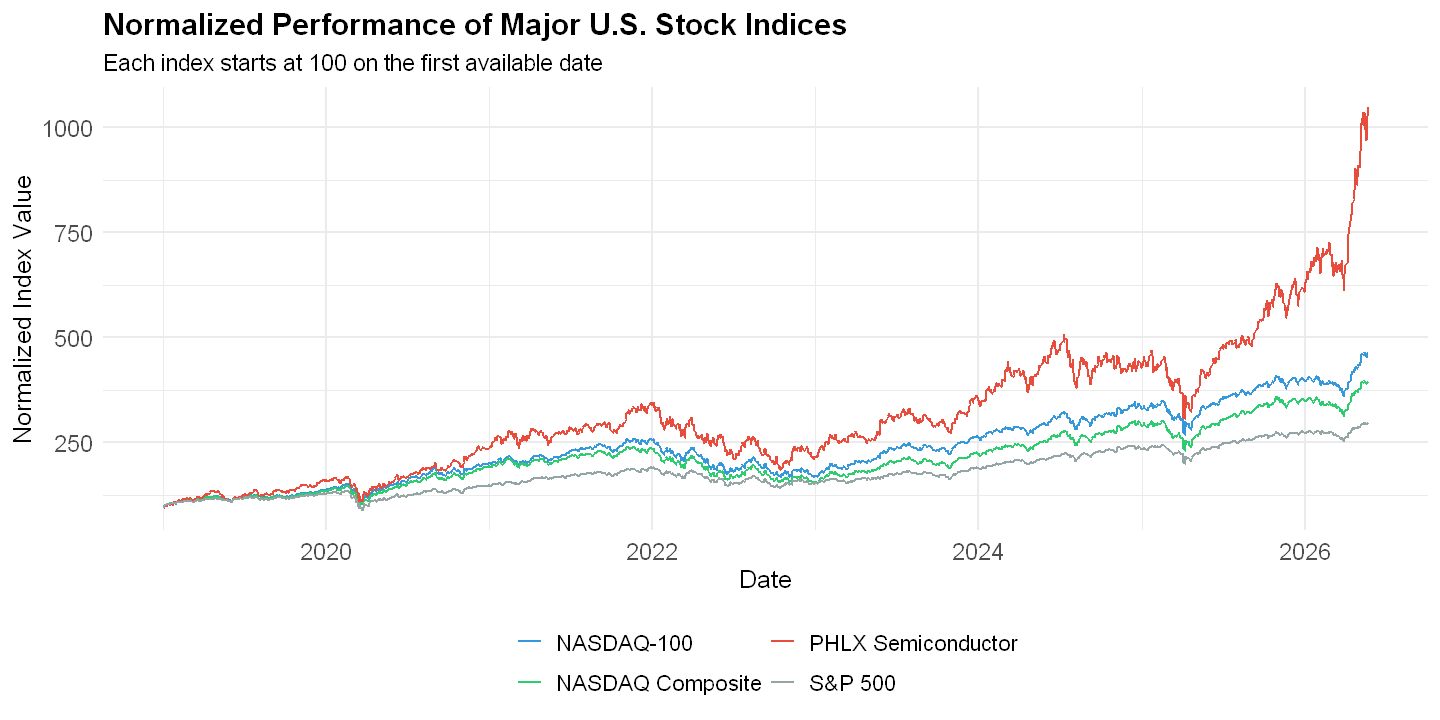

In [20]:
options(repr.plot.width = plot_width_wide, repr.plot.height = plot_height_std)

normalized_long <- index_normalized %>%
  select(date, ends_with("Normalized")) %>%
  pivot_longer(cols = -date, names_to = "index", values_to = "normalized_value") %>%
  mutate(index = gsub(" Normalized", "", index))

ggplot(normalized_long, aes(x = date, y = normalized_value, color = index)) +
  geom_line(linewidth = 0.8) +
  scale_color_manual(values = index_colors) +
  labs(
    title = "Normalized Performance of Major U.S. Stock Indices",
    subtitle = "Each index starts at 100 on the first available date",
    x = "Date",
    y = "Normalized Index Value",
    color = NULL
  ) +
  theme_minimal(base_size = font_base) +
  theme(
    plot.title       = element_text(size = font_title, face = "bold"),
    plot.subtitle    = element_text(size = font_subtitle + 1),
    axis.text        = element_text(size = font_axis + 2),
    axis.title       = element_text(size = font_axis + 3),
    legend.position  = "bottom",
    legend.direction = "horizontal",
    legend.text      = element_text(size = font_legend)
  ) +
  guides(color = guide_legend(nrow = 2))

## 15. Plot rolling volatility over time

This chart shows the 30-day rolling standard deviation of daily returns for each index. Rather than plotting individual daily moves — which are too dense to read — the rolling window smooths the signal into a volatility envelope. Periods where an index's line sits higher indicate sustained turbulence; spikes show acute stress events such as the COVID crash in early 2020. The fixed y-axis makes the relative volatility levels directly comparable across indices.

Warning message:
"Removed 120 rows containing missing values or values outside the scale range
(`geom_line()`)."


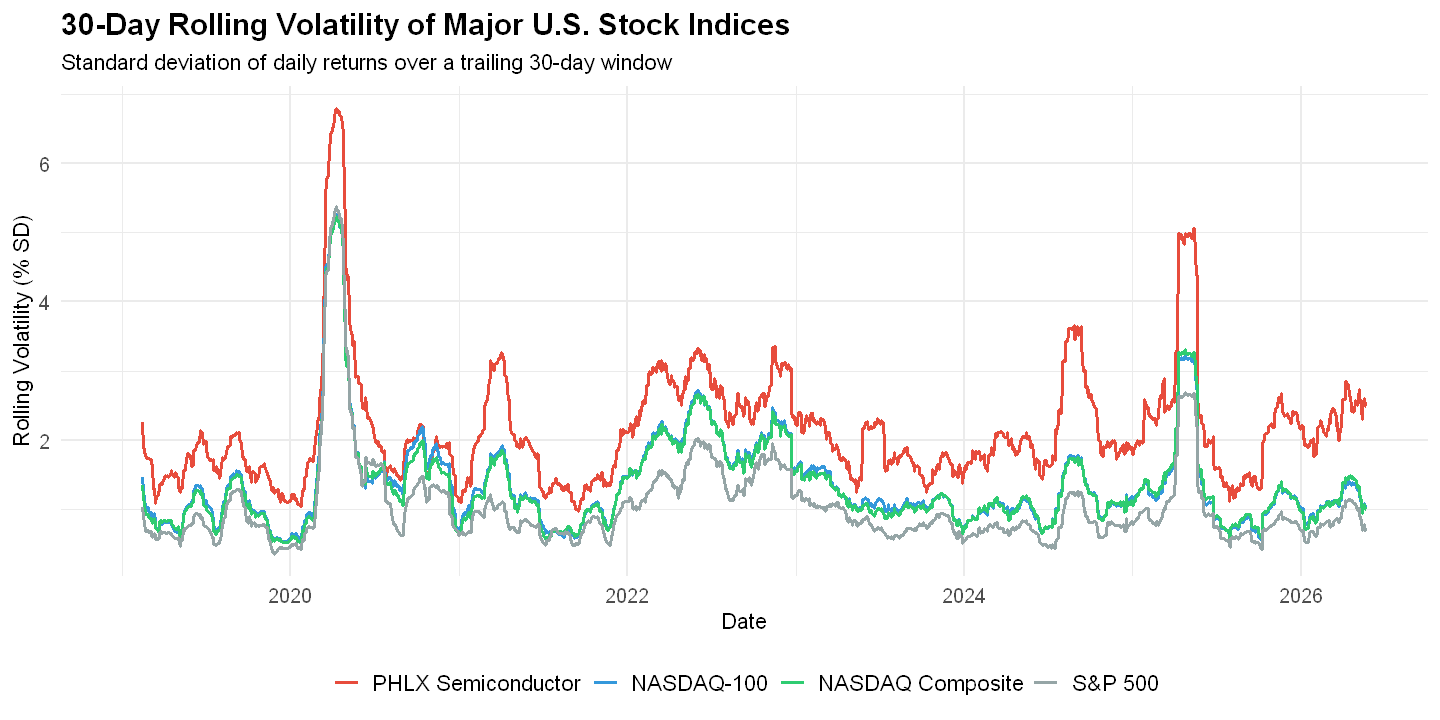

In [21]:
options(repr.plot.width = plot_width_wide, repr.plot.height = plot_height_std)

rolling_vol <- index_returns %>%
  arrange(date) %>%
  mutate(
    `PHLX Semiconductor` = zoo::rollapply(`PHLX Semiconductor Return`, 30, sd, fill = NA, align = "right"),
    `NASDAQ-100`         = zoo::rollapply(`NASDAQ-100 Return`,         30, sd, fill = NA, align = "right"),
    `NASDAQ Composite`   = zoo::rollapply(`NASDAQ Composite Return`,   30, sd, fill = NA, align = "right"),
    `S&P 500`            = zoo::rollapply(`S&P 500 Return`,            30, sd, fill = NA, align = "right")
  ) %>%
  select(date, `PHLX Semiconductor`, `NASDAQ-100`, `NASDAQ Composite`, `S&P 500`) %>%
  pivot_longer(-date, names_to = "index", values_to = "rolling_vol") %>%
  mutate(index = factor(index, levels = names(index_colors)))

ggplot(rolling_vol, aes(x = date, y = rolling_vol, color = index)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = index_colors) +
  labs(
    title = "30-Day Rolling Volatility of Major U.S. Stock Indices",
    subtitle = "Standard deviation of daily returns over a trailing 30-day window",
    x = "Date",
    y = "Rolling Volatility (% SD)",
    color = NULL
  ) +
  theme_minimal(base_size = font_base) +
  theme(
    plot.title      = element_text(size = font_title, face = "bold"),
    plot.subtitle   = element_text(size = font_subtitle),
    axis.text       = element_text(size = font_axis),
    axis.title      = element_text(size = font_axis + 1),
    legend.position = "bottom",
    legend.text     = element_text(size = font_legend)
  )

## 16. Plot volatility comparison

This chart ranks the indices by the standard deviation of daily returns. Higher standard deviation means greater daily volatility.

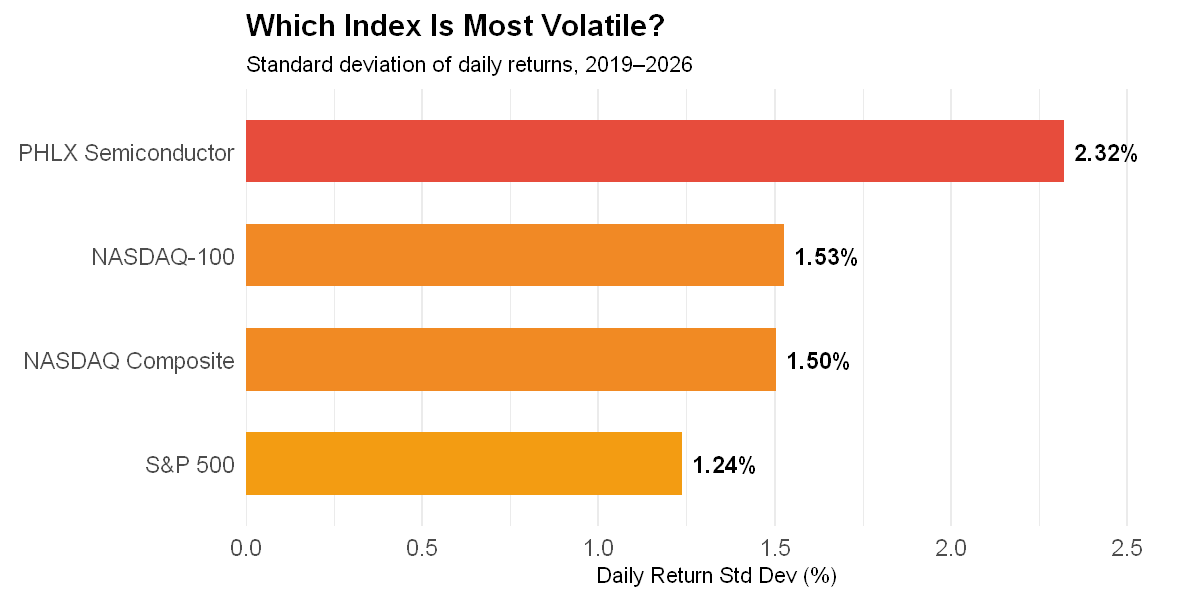

In [22]:
options(repr.plot.width = plot_width_normal, repr.plot.height = plot_height_short)

return_stats %>%
  mutate(
    index = gsub(" Return", "", index),
    index = reorder(index, sd_return)
  ) %>%
  ggplot(aes(x = index, y = sd_return, fill = sd_return)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = sprintf("%.2f%%", sd_return)), hjust = -0.15, size = 5, fontface = "bold") +
  coord_flip() +
  scale_fill_gradient(low = "#f39c12", high = color_neg) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(
    title = "Which Index Is Most Volatile?",
    subtitle = "Standard deviation of daily returns, 2019–2026",
    x = NULL,
    y = "Daily Return Std Dev (%)"
  ) +
  theme_minimal(base_size = font_base + 1) +
  theme(
    plot.title         = element_text(size = font_title, face = "bold"),
    plot.subtitle      = element_text(size = font_subtitle),
    axis.text          = element_text(size = font_axis + 2),
    axis.title.x       = element_text(size = font_axis + 1),
    panel.grid.major.y = element_blank()
  )

## 17. Risk-adjusted performance

Raw returns and volatility tell only half the story. An index that gains more but swings wildly may not actually be a better investment than a steadier one, once risk is accounted for. This section uses two standard measures:

### Sharpe Ratio
The Sharpe Ratio measures return earned per unit of volatility, above the risk-free rate:

$$\text{Sharpe} = \frac{\bar{r} - r_f}{\sigma}$$

where $\bar{r}$ is the mean daily return, $r_f$ is the daily risk-free rate (3-Month T-Bill, `TB3MS`), and $\sigma$ is the standard deviation of daily returns. The result is annualised by multiplying by $\sqrt{252}$. A higher Sharpe Ratio means better return per unit of risk.

### Calmar Ratio
The Calmar Ratio measures annualised return relative to the maximum drawdown — the largest peak-to-trough loss over the period:

$$\text{Calmar} = \frac{\text{Annualised Return}}{\text{|Max Drawdown|}}$$

It captures how much an investor was rewarded relative to the worst-case loss they had to endure. A higher Calmar Ratio means better return per unit of drawdown pain.

In [23]:
# Mean daily risk-free rate over the sample
mean_rf_daily <- mean(tbill_ff$rf_daily, na.rm = TRUE)

# Helper: max drawdown for a price series
max_drawdown <- function(prices) {
  peak <- cummax(prices)
  drawdown <- (prices - peak) / peak
  min(drawdown, na.rm = TRUE)
}

# Number of trading days in sample (for annualisation)
n_days <- nrow(index_clean)
n_years <- n_days / 252

risk_adjusted <- tibble(
  index = c("S&P 500", "NASDAQ-100", "NASDAQ Composite", "PHLX Semiconductor"),
  mean_daily_return = c(
    mean(index_returns$`S&P 500 Return`, na.rm = TRUE) / 100,
    mean(index_returns$`NASDAQ-100 Return`, na.rm = TRUE) / 100,
    mean(index_returns$`NASDAQ Composite Return`, na.rm = TRUE) / 100,
    mean(index_returns$`PHLX Semiconductor Return`, na.rm = TRUE) / 100
  ),
  sd_daily_return = c(
    sd(index_returns$`S&P 500 Return`, na.rm = TRUE) / 100,
    sd(index_returns$`NASDAQ-100 Return`, na.rm = TRUE) / 100,
    sd(index_returns$`NASDAQ Composite Return`, na.rm = TRUE) / 100,
    sd(index_returns$`PHLX Semiconductor Return`, na.rm = TRUE) / 100
  ),
  max_dd = c(
    max_drawdown(index_clean$`S&P 500`),
    max_drawdown(index_clean$`NASDAQ-100`),
    max_drawdown(index_clean$`NASDAQ Composite`),
    max_drawdown(index_clean$`PHLX Semiconductor`)
  ),
  total_return = c(
    last(index_clean$`S&P 500`) / first(index_clean$`S&P 500`) - 1,
    last(index_clean$`NASDAQ-100`) / first(index_clean$`NASDAQ-100`) - 1,
    last(index_clean$`NASDAQ Composite`) / first(index_clean$`NASDAQ Composite`) - 1,
    last(index_clean$`PHLX Semiconductor`) / first(index_clean$`PHLX Semiconductor`) - 1
  )
) %>%
  mutate(
    annualised_return = round((1 + total_return)^(1 / n_years) * 100 - 100, 2),
    max_dd            = round(max_dd * 100, 2),
    sharpe            = round((mean_daily_return - mean_rf_daily) / sd_daily_return * sqrt(252), 3),
    calmar            = round(annualised_return / abs(max_dd), 3)
  ) %>%
  select(index, annualised_return, max_dd, sharpe, calmar)

tbl_html <- risk_adjusted %>%
  gt() %>%
  tab_header(
    title    = "Risk-Adjusted Performance of Major U.S. Stock Indices",
    subtitle = "January 2019 – May 2026  |  Risk-free rate: 3-Month T-Bill (TB3MS)"
  ) %>%
  cols_label(
    index             = "Index",
    annualised_return = "Annualised Return (%)",
    max_dd            = "Max Drawdown (%)",
    sharpe            = "Sharpe Ratio",
    calmar            = "Calmar Ratio"
  ) %>%
  fmt_number(columns = c(annualised_return, max_dd), decimals = 2) %>%
  fmt_number(columns = c(sharpe, calmar), decimals = 3) %>%
  tab_style(
    style = cell_fill(color = color_highlight),
    locations = cells_body(columns = annualised_return,
                           rows = annualised_return == max(annualised_return))
  ) %>%
  tab_style(
    style = cell_fill(color = color_highlight),
    locations = cells_body(columns = max_dd,
                           rows = max_dd == max(max_dd))
  ) %>%
  tab_style(
    style = cell_fill(color = color_highlight),
    locations = cells_body(columns = sharpe,
                           rows = sharpe == max(sharpe))
  ) %>%
  tab_style(
    style = cell_fill(color = color_highlight),
    locations = cells_body(columns = calmar,
                           rows = calmar == max(calmar))
  ) %>%
  tab_style(
    style = list(cell_text(weight = "bold", color = color_header_text),
                 cell_fill(color = color_header_bg)),
    locations = cells_column_labels()
  ) %>%
  tab_footnote("Higher Sharpe and Calmar ratios indicate better risk-adjusted performance.") %>%
  opt_row_striping() %>%
  opt_table_font(font = "Arial") %>%
  tab_options(
    table.width   = pct(80),
    heading.align = "left"
  ) %>%
  as_raw_html()

IRdisplay::display_html(tbl_html)

Higher Sharpe and Calmar ratios indicate better risk-adjusted performance.


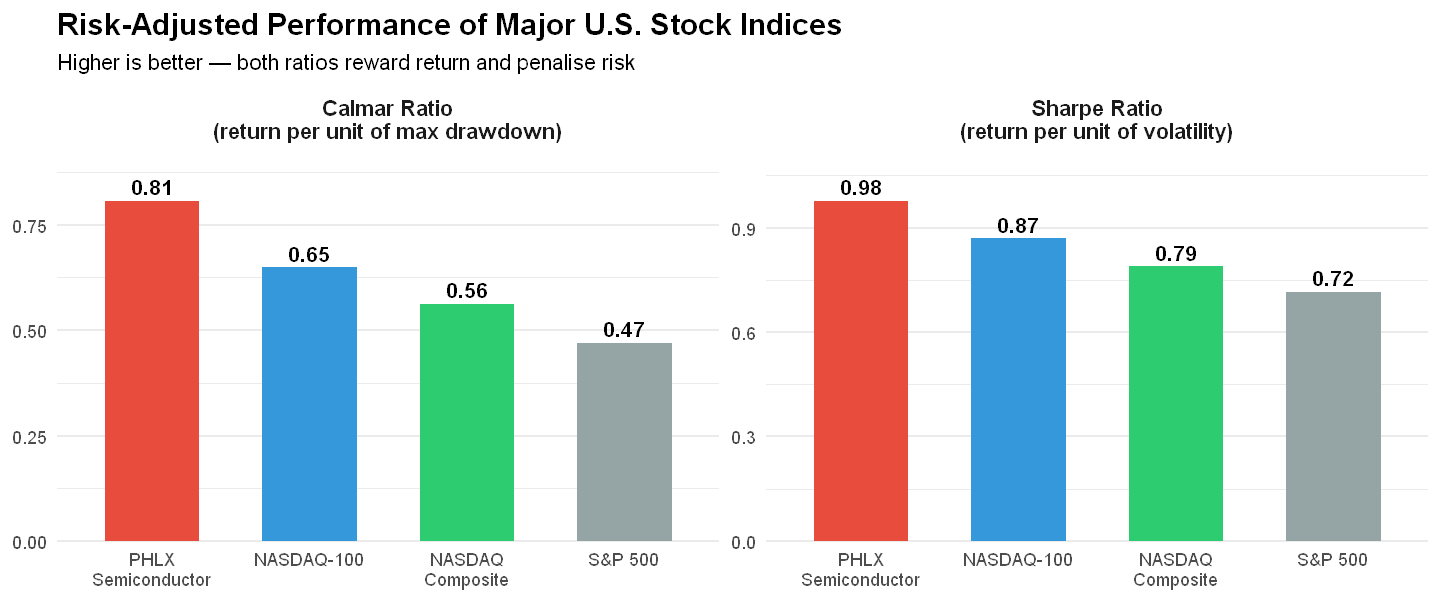

In [29]:
options(repr.plot.width = plot_width_wide, repr.plot.height = plot_height_short)

risk_long <- risk_adjusted %>%
  select(index, sharpe, calmar) %>%
  pivot_longer(-index, names_to = "metric", values_to = "value") %>%
  mutate(
    metric = recode(metric,
      "sharpe" = "Sharpe Ratio\n(return per unit of volatility)",
      "calmar" = "Calmar Ratio\n(return per unit of max drawdown)"
    ),
    index = factor(index, levels = names(index_colors))
  )

ggplot(risk_long, aes(x = index, y = value, fill = index)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = sprintf("%.2f", value)), vjust = -0.4, size = 4.5, fontface = "bold") +
  facet_wrap(~ metric, scales = "free_y") +
  scale_fill_manual(values = index_colors) +
  scale_x_discrete(labels = c(
    "PHLX Semiconductor" = "PHLX
Semiconductor",
    "NASDAQ-100"         = "NASDAQ-100",
    "NASDAQ Composite"   = "NASDAQ
Composite",
    "S&P 500"            = "S&P 500"
  )) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(
    title = "Risk-Adjusted Performance of Major U.S. Stock Indices",
    subtitle = "Higher is better — both ratios reward return and penalise risk",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = font_base) +
  theme(
    plot.title         = element_text(size = font_title, face = "bold"),
    plot.subtitle      = element_text(size = font_subtitle),
    axis.text.x        = element_text(size = font_axis - 1),
    axis.text.y        = element_text(size = font_axis - 1),
    strip.text         = element_text(size = font_strip, face = "bold"),
    panel.grid.major.x = element_blank()
  )

## Main findings from the executed output

- The cleaned dataset contains **1,858 daily observations** from **January 2, 2019** through **May 22, 2026**.
- Over this period, the **PHLX Semiconductor Index** had by far the strongest cumulative performance, rising about **947%**.
- The **NASDAQ-100** rose about **363%**, and the **NASDAQ Composite** rose about **295%**.
- The **S&P 500** rose about **198%**, which was strong but lower than the more technology-heavy indices.
- The same index that performed best also had the highest volatility. The **PHLX Semiconductor Index** had the largest standard deviation of daily returns, about **2.32%**.
- The **S&P 500** had the lowest daily-return volatility, about **1.24%**, consistent with its broader diversification.
- The **NASDAQ-100** and **NASDAQ Composite** moved almost identically on a daily-return basis, with a correlation of about **0.993**. A correlation this close to 1.0 means the two indices are effectively redundant from a diversification standpoint — an investor holding both gains no meaningful risk reduction compared to holding either one alone. The NASDAQ-100's tighter focus on the 100 largest non-financial Nasdaq firms produced marginally higher returns (+363% vs +295%) with nearly identical volatility, making it the more efficient choice of the two.
- The semiconductor index was still strongly correlated with the other indices, but less tightly. Its correlation with the S&P 500 was about **0.827**.
- A fifth FRED series — the **3-Month Treasury Bill rate (`TB3MS`)** — was fetched separately as the risk-free rate proxy. Because it is a monthly series, it was converted to a daily equivalent and forward-filled to align with the daily index dates.
- On a **Sharpe Ratio** basis (annualised return per unit of daily volatility, above the risk-free rate), the **PHLX Semiconductor Index** ranked highest (0.977), followed by NASDAQ-100 (0.870), NASDAQ Composite (0.789), and S&P 500 (0.716). Despite its high volatility, PHLX's returns were large enough to produce the best risk-adjusted score by this measure.
- On a **Calmar Ratio** basis (annualised return divided by the absolute maximum drawdown), the **PHLX Semiconductor Index** also ranked highest (0.807), ahead of NASDAQ-100 (0.650), NASDAQ Composite (0.563), and S&P 500 (0.470). Its deeper drawdown of −46.5% was more than offset by its 37.5% annualised return.
- The main pattern is clear: **PHLX leads on every metric — raw return, Sharpe, and Calmar — but the advantage compresses sharply once risk is accounted for**. A ~5× raw return advantage over the S&P 500 narrows to a ~1.4× Sharpe advantage, meaning the additional risk was rewarded, but not proportionally.


## What I learned from inspecting the data

After importing the data from the FRED API, I found that the dataset is structured as a daily time series with one observation per date and one value for each index. After joining the four index series and keeping complete observations, the final dataset contained **1,858 observations** from **January 2, 2019** to **May 22, 2026**.

The raw index levels are not ideal for direct comparison because each index has a different base value. Normalizing each index to 100 at the beginning of the sample solves this and makes cumulative performance directly comparable.

The normalized performance results show that the **PHLX Semiconductor Index** increased the most, rising about **947%** over the sample period. The **NASDAQ-100** rose about **363%**, the **NASDAQ Composite** rose about **295%**, and the **S&P 500** rose about **198%**. Semiconductor stocks substantially outperformed broader equity indices during this period.

The daily-return statistics show the trade-off. The **PHLX Semiconductor Index** had the highest daily volatility, with a daily-return standard deviation of about **2.32%**. The **S&P 500** had the lowest volatility, about **1.24%**. The NASDAQ-100 and NASDAQ Composite were in the middle, at about **1.53%** and **1.50%** respectively.

The correlation matrix reveals an important structural finding. The NASDAQ-100 and NASDAQ Composite had a daily-return correlation of about **0.993** — effectively 1.0 in practical terms. This means the two indices moved in the same direction on virtually every trading day across seven years. For an investor considering Nasdaq market exposure, holding both indices simultaneously provides no meaningful diversification benefit: when one falls, the other falls by almost the same amount. The NASDAQ-100, with its tighter focus on the 100 largest non-financial Nasdaq-listed firms, delivered marginally higher returns (+363% vs +295%) at nearly identical volatility — making it the more return-efficient of the two Nasdaq indices. Including both in a portfolio analysis is appropriate for research purposes, but in a real portfolio context they would be treated as substitutes, not complements. The semiconductor index was also strongly correlated with the broader market (0.827 with the S&P 500), but its lower correlation leaves more room for independent behaviour during stress events.

To go beyond raw returns and volatility, a fifth FRED series — the **3-Month Treasury Bill rate (`TB3MS`)** — was added as the risk-free rate proxy. This monthly series was converted to a daily equivalent and forward-filled to align with the daily index dates. Using `TB3MS` captures the meaningful variation in the risk-free rate across the sample, from near zero in 2020–2021 to above 5% by 2023–2024.

The **Sharpe Ratio** results show that the **PHLX Semiconductor Index** ranked highest (0.977), not lowest. Despite its high daily volatility of 2.32%, PHLX's annualised return of 37.5% was large enough to produce the best return-per-unit-of-risk score. The S&P 500 (0.716) and NASDAQ-100 (0.870) ranked below PHLX on this measure. The key nuance is that PHLX's ~5× raw return advantage over the S&P 500 compresses to a ~1.4× Sharpe advantage — the risk was rewarded, but not at the same rate as the headline return implies. The **Calmar Ratio** tells the same story: PHLX ranked first (0.807), with S&P 500 last (0.470). The S&P 500's shallower drawdown of −33.9% was not enough to overcome the gap in annualised return (15.95% vs 37.51%).


## The "so what?" explanation

This analysis matters because major stock indices are not interchangeable. The S&P 500 is often treated as a broad proxy for the U.S. stock market, but technology-heavy and semiconductor-focused indices can behave very differently. The output shows that from 2019 to 2026, the semiconductor index produced much higher cumulative gains than the S&P 500, NASDAQ-100, or NASDAQ Composite.

The important trade-off is risk. The PHLX Semiconductor Index had the highest total gain, but it also had the highest daily-return volatility. This means that investors who wanted exposure to semiconductors were compensated with much higher growth during this period, but they also had to tolerate larger daily swings. The S&P 500 had lower cumulative growth, but it also had the lowest volatility, which is consistent with its broader diversification across 500 large-cap companies.

A separate but important finding concerns the NASDAQ-100 and NASDAQ Composite. These two indices had a daily-return correlation of 0.993 — close enough to 1.0 that they are effectively the same index for practical purposes. An investor who holds both believing they are diversifying their Nasdaq exposure is mistaken: the two indices fall and rise together on virtually every trading day. The implication is that within Nasdaq market exposure, index selection is largely redundant — the NASDAQ-100 and NASDAQ Composite offer the same risk profile, with NASDAQ-100 delivering marginally higher returns (+363% vs +295%) at nearly identical volatility. If forced to choose one, the NASDAQ-100 is more efficient. If the goal is genuine diversification away from Nasdaq concentration, neither index achieves it — that requires moving toward the S&P 500 or PHLX, which have lower correlations to each other and to the broader Nasdaq market.

Adding a risk-free rate benchmark — the 3-Month Treasury Bill (`TB3MS`) from FRED — allows a more complete picture. During the 2022–2024 period, short-term interest rates rose above 5%, meaning investors could earn meaningful returns without taking on any equity risk. Measuring equity performance against this baseline, rather than against zero, is what the Sharpe and Calmar ratios capture.

The Sharpe Ratio reveals that the PHLX Semiconductor Index's outsized raw return did translate into the highest risk-adjusted return — it led all four indices with a Sharpe of 0.977, compared with 0.870 for NASDAQ-100, 0.789 for NASDAQ Composite, and 0.716 for S&P 500. The critical insight, however, is one of proportionality: a ~5× raw return advantage over the S&P 500 compressed to only a ~1.4× Sharpe advantage. Volatility partially eroded the return edge, even though it did not reverse the ranking. The Calmar Ratio confirms this: PHLX ranked first (0.807) on this measure as well, ahead of NASDAQ-100 (0.650) and S&P 500 (0.470). The semiconductor index's deeper drawdown of −46.5% was more than compensated by its higher annualised return of 37.5%.

This matters to investors, financial advisors, and portfolio managers because raw cumulative performance, while directionally correct here, overstates the semiconductor edge once risk is accounted for. A portfolio concentrated in semiconductors delivered the highest raw returns and the highest risk-adjusted returns in this sample — but the margin shrinks considerably once volatility and drawdown are priced in. The right choice depends on whether an investor prioritises raw return (PHLX), the best available balance of return and drawdown (NASDAQ-100), or the least volatility (S&P 500).

The broader lesson is that "the stock market" is not one thing, and neither is "risk" or "diversification." Different indices carry different return profiles, different volatility profiles, and different drawdown characteristics. A near-perfect correlation between two indices signals redundancy, not diversification. Risk-adjusted metrics like the Sharpe and Calmar ratios are tools for comparing these trade-offs on a common scale — and in this case, they reveal that the semiconductor premium was real but non-proportional, and that Nasdaq market exposure is more concentrated than the existence of two separate indices might imply.
